## Загрузка исходных датасетов

- `load_from_cdaweb` - параметр, отвечающий за источник откуда будет произведена загрузка данных.
- `loader` - экзампляр класса, обеспичвающий загрузку данных.
- `get_*_data()` - соответственные методы по загрузке определённых данных.

| Вызов | Содержимое колонок |
|--------|---------------------|
| `get_ssc_data()` | **Time** — время; **Latitude**, **Longitude** — широта/долгота (GSM); **L** — L-шелл; **GSM_X**, **GSM_Y**, **GSM_Z** — позиция аппарата в GSM (км). |
| `get_fgm_data()` | **Time**; **GSM_Bx**, **GSM_By**, **GSM_Bz** — вектор магнитного поля в GSM (нТ). |
| `get_esa_data(particle="ion")` | **Time**; **GSM_Vix**, **GSM_Viy**, **GSM_Viz** — скорость ионов в GSM (км/с). |
| `get_esa_data(particle="electron")` | **Time**; **GSM_Vex**, **GSM_Vey**, **GSM_Vez** — скорость электронов в GSM (км/с). |
| `get_efi_data()` | **Time**; **GSM_Ex**, **GSM_Ey**, **GSM_Ez** — электрическое поле в GSM (единицы как в CDF, часто мВ/м). |
| `get_sta_data()` | **Time**; **GSM_Vsx**, **GSM_Vsy**, **GSM_Vsz** — скорость спутника в GSM (км/с). |
| `get_omn_data()` | **Time**; **FP** — динамическое давление солнечного ветра; **Bz_GSM** — компонента Bz в GSM. |
| `get_shue_data()` | **Time**; **L** — L-шелл; **MLT** — магнитное локальное время (из `Longitude`); **r** — параметр Shue (SSC+OMNI). |

Общее: после загрузки отброшены строки без валидного **Time**, дубликаты по **Time** удалены. Дополнительно в OMNI интерполируются пропуски в `FP` и `Bz_GSM` (в обе стороны), чтобы интервалы доступности не дробились из-за `None`. Интервал и спутник задаются в `config.reading`; OMNI — околоземный ряд, не привязан к букве спутника по смыслу данных.

In [2]:
from backend.src.io.loader import DataDownloading
from backend.src.config import config
from backend.src.processing.utils.h_parameter_range import show_h_parameter_range

In [3]:
load_from_cdaweb = False
loader = DataDownloading(config, load_from_cdaweb=load_from_cdaweb)

In [4]:
ssc_data = loader.get_ssc_data()
fgm_data = loader.get_fgm_data()
esa_ion_data = loader.get_esa_data(particle="ion")
# esa_electron_data = loader.get_esa_data(particle="electron")
efi_data = loader.get_efi_data()
sta_data = loader.get_sta_data()
omn_data = loader.get_omn_data()
shue_data = loader.get_shue_data()

## Пересечение промежутков

In [1]:
from datetime import timedelta

from backend.src.processing import AvailabilityIntervals
from backend.src.processing.intersections import intersect_many, save_intervals_csv, summarize_intervals

In [5]:
availability = AvailabilityIntervals(show_progress=True)

ssc_intervals = availability.from_dataframe(ssc_data, "ssc")
fgm_intervals = availability.from_dataframe(fgm_data, "fgm")
esa_ion_intervals = availability.from_dataframe(esa_ion_data, "esa_ion")
# esa_electron_intervals = availability.from_dataframe(esa_electron_data, "esa_electron")
efi_intervals = availability.from_dataframe(efi_data, "efi")
sta_intervals = availability.from_dataframe(sta_data, "sta")
shue_intervals = availability.from_dataframe(shue_data, "shue")

Определение shue интервалов: 100%|██████████| 3/3 [00:00<00:00, 7273.36it/s]


In [6]:
interval_intersections = intersect_many(
    interval_groups=[
        ssc_intervals,
        sta_intervals,
        efi_intervals,
        fgm_intervals,
        esa_ion_intervals,
        shue_intervals
    ],
    min_duration=timedelta(hours=1),
)

save_intervals_csv(
    intervals=interval_intersections,
    output_path=availability.csv_output_dir / "intersections_availability_periods.csv",
)

summarize_intervals(interval_intersections)

{'count': 4,
 'first': (Timestamp('2017-01-01 20:35:13'), Timestamp('2017-01-02 00:21:13')),
 'last': (Timestamp('2017-01-02 23:44:00'), Timestamp('2017-01-03 03:04:57'))}

## Визуализация пересечений

In [8]:
# availability.show(esa_ion_data, esa_ion_intervals, "esa_ion")

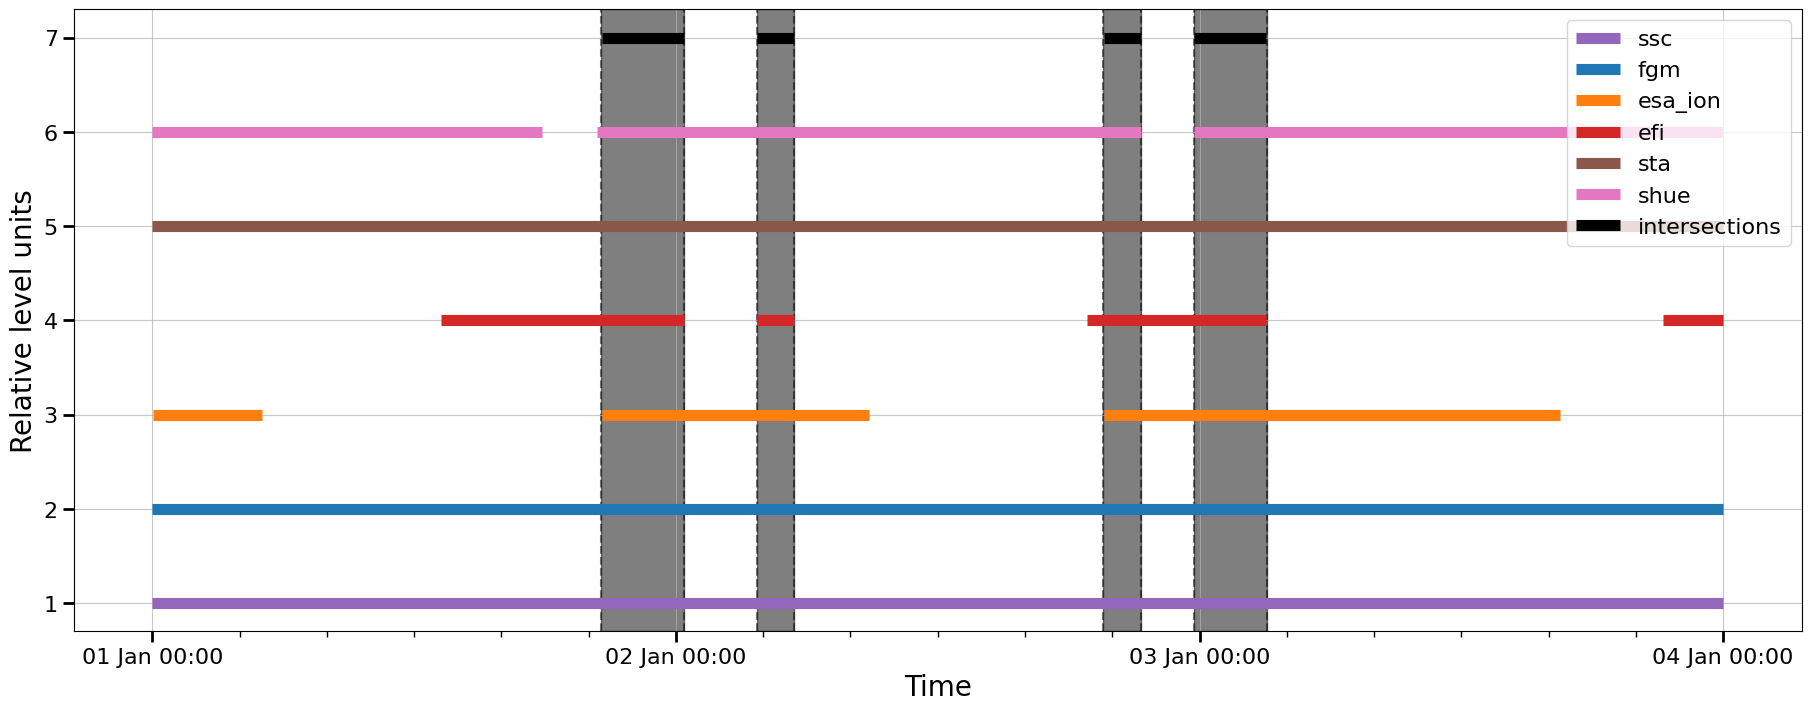

In [9]:
intervals_list = [
    {'intervals': ssc_intervals, "data_type": "ssc"},
    {'intervals': fgm_intervals, "data_type": "fgm"},
    {'intervals': esa_ion_intervals, "data_type": "esa_ion"},
    {'intervals': efi_intervals, "data_type": "efi"},
    {'intervals': sta_intervals, "data_type": "sta"},
    {'intervals': shue_intervals, "data_type": "shue"},
    {'intervals': interval_intersections, "data_type": "intersections"},
]

availability.show_intervals(ssc_data, intervals_list)

## Модель Shue 1997 года

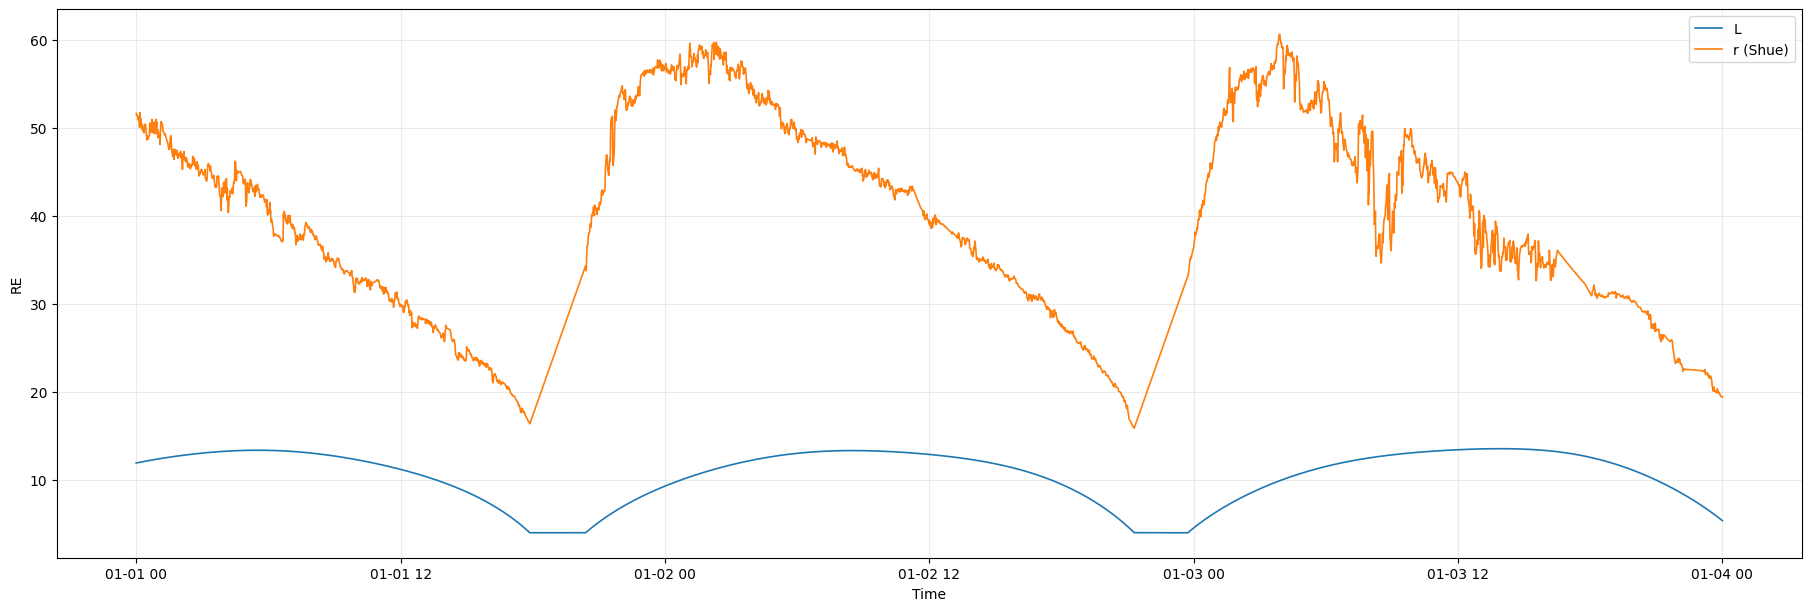

In [10]:
import matplotlib.pyplot as plt
import pandas as pd

plot_df = shue_data.copy()


plot_df["Time"] = pd.to_datetime(plot_df["Time"], utc=True, errors="coerce").dt.tz_localize(None)
plot_df = plot_df.dropna(subset=["Time", "L", "r"]).sort_values("Time")

fig, ax = plt.subplots(1, 1, figsize=(18, 6), layout="constrained", sharex=True)
ax.plot(plot_df["Time"], plot_df["L"], label="L", linewidth=1.2)
ax.plot(plot_df["Time"], plot_df["r"], label="r (Shue)", linewidth=1.2)

ax.set_xlabel("Time")
ax.set_ylabel("RE")
ax.grid(True, alpha=0.25)
ax.legend()
plt.show()

## Матрицы доступности

In [10]:
from backend.src.processing.satellite_matrix import SatelliteMatrix

satellite_matrix = SatelliteMatrix(ssc_data, "satellite").get_satellite_matrix()

Подсчёт матрицы нахождения спутника на орбите: 100%|██████████| 4321/4321 [00:00<00:00, 51233.19it/s]


In [11]:
ssc_matrix_generator = SatelliteMatrix(ssc_data, "ssc")

ssc_matrix = ssc_matrix_generator.get_availability_matrix(periods = ssc_intervals)
rel_ssc_matrix = ssc_matrix_generator.get_relative_availability_matrix(periods = ssc_intervals, satellite_matrix = satellite_matrix)

Обработка периодов доступности данных для инструмента ssc: 100%|██████████| 1/1 [00:00<00:00, 10.79it/s]
Обработка периодов доступности данных для инструмента ssc: 100%|██████████| 1/1 [00:00<00:00, 11.08it/s]


In [12]:
sta_matrix_generator = SatelliteMatrix(ssc_data, "sta")

sta_matrix = sta_matrix_generator.get_availability_matrix(periods = sta_intervals)
rel_sta_matrix = sta_matrix_generator.get_relative_availability_matrix(periods = sta_intervals, satellite_matrix = satellite_matrix)

Обработка периодов доступности данных для инструмента sta: 100%|██████████| 1/1 [00:00<00:00, 10.99it/s]
Обработка периодов доступности данных для инструмента sta: 100%|██████████| 1/1 [00:00<00:00, 11.04it/s]


In [14]:
efi_matrix_generator = SatelliteMatrix(ssc_data, "efi")

efi_matrix = efi_matrix_generator.get_availability_matrix(periods = efi_intervals)
rel_efi_matrix = efi_matrix_generator.get_relative_availability_matrix(periods = efi_intervals, satellite_matrix = satellite_matrix)

Обработка периодов доступности данных для инструмента efi: 100%|██████████| 4/4 [00:00<00:00, 111.53it/s]
Обработка периодов доступности данных для инструмента efi: 100%|██████████| 4/4 [00:00<00:00, 122.13it/s]


In [15]:
fgm_matrix_generator = SatelliteMatrix(ssc_data, "fgm")

fgm_matrix = fgm_matrix_generator.get_availability_matrix(periods = fgm_intervals)
rel_fgm_matrix = fgm_matrix_generator.get_relative_availability_matrix(periods = fgm_intervals, satellite_matrix = satellite_matrix)

Обработка периодов доступности данных для инструмента fgm: 100%|██████████| 1/1 [00:00<00:00, 10.80it/s]
Обработка периодов доступности данных для инструмента fgm: 100%|██████████| 1/1 [00:00<00:00, 10.97it/s]


In [16]:
esa_ion_matrix_generator = SatelliteMatrix(ssc_data, "ESA ion")
# Аналогично для электронов создаётся

esa_ion_matrix = esa_ion_matrix_generator.get_availability_matrix(periods = esa_ion_intervals)
rel_esa_ion_matrix = esa_ion_matrix_generator.get_relative_availability_matrix(periods = esa_ion_intervals, satellite_matrix = satellite_matrix)

Обработка периодов доступности данных для инструмента ESA ion: 100%|██████████| 3/3 [00:00<00:00, 57.33it/s]
Обработка периодов доступности данных для инструмента ESA ion: 100%|██████████| 3/3 [00:00<00:00, 57.15it/s]


In [17]:
availability_matrix_generator = SatelliteMatrix(ssc_data, "Availability")

availability_matrix = availability_matrix_generator.get_availability_matrix(periods = interval_intersections)
rel_availability_matrix = availability_matrix_generator.get_relative_availability_matrix(periods = interval_intersections, satellite_matrix = satellite_matrix)

Обработка периодов доступности данных для инструмента Availability: 100%|██████████| 4/4 [00:00<00:00, 226.03it/s]
Обработка периодов доступности данных для инструмента Availability: 100%|██████████| 4/4 [00:00<00:00, 247.46it/s]


## Дальше блок изображений, но он будет потом

## Интерполяция данных